In [18]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1. Load features
X = pd.read_csv("../src/features.csv")
display(X)
X['file_name'] = X['file_name'].str.replace("Data/After_May/MATLAB ", "", regex=False).str.strip()
# 2. Load labels with new header
y_df = pd.read_csv("../WebApp/labels.csv")

# 3. Merge by file_name (inner join to keep only common entries)
df = pd.merge(X, y_df, on="file_name", how="inner")

# 4. Extract features and labels
y = df['label']  # Replace 'label' with actual column name if different
X_clean = df.drop(columns=["file_name", "label"])

,file_name,spectral_entropy,spectral_centroid,spectral_flatness,spectral_bandwidth,std_dev_time_diff,mean_time_diff,median_time_diff,max_peak,median_peak,std_peak,avg_peaks_per_second,sum_peak_magnitude,percent_time_above_threshold,num_boilings,unused_peak_proportion
0,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,4.931438,142.972639,0.485231,167.493065,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,5.441444,212.265411,0.246755,141.800934,0.047587,0.185100,0.18960,0.214318,0.175477,0.019744,0.555717,1.072556,0.000500,2.0,0.0
2,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,5.903335,245.487625,0.258097,117.587509,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
3,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,5.869558,246.528657,0.285455,131.932812,0.000865,0.348300,0.34825,0.314323,0.269887,0.028402,2.541507,3.928180,0.000300,1.0,0.0
4,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,5.441887,223.378682,0.222840,135.732205,0.006336,0.608567,0.60470,0.216213,0.201289,0.017548,1.013950,0.787064,0.000150,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,5.107883,193.136721,0.225410,136.588878,0.001333,0.056987,0.05690,0.145812,0.115100,0.015860,14.830528,61.594580,0.002867,3.0,0.0
284,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,5.734099,303.668762,0.219485,94.584928,0.040742,0.191896,0.18540,0.177590,0.152426,0.022370,4.505863,7.726517,0.002680,1.0,0.0
285,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,5.831550,288.347876,0.357257,129.846672,2.107394,3.104300,3.25750,0.083921,0.036853,0.022598,9.926629,0.309335,0.000235,0.0,1.0
286,/Users/zach/Desktop/Acoustic-Space-Boiling/Dat...,5.349661,170.903613,0.549674,173.115888,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0


In [10]:
# 5. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

# 6. Train the decision tree
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 7. Evaluate
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# 8. Visualize tree
plt.figure(figsize=(40, 20))  # Increase width and height
plot_tree(
    clf,
    feature_names=X_clean.columns,
    class_names=[str(cls) for cls in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=12  # Bump up font size too
)
plt.title("Decision Tree Classifier", fontsize=20)

# Show it big in notebook
plt.show()

# Optional: Save to file if you want to open it in full resolution
plt.savefig("decision_tree.png", dpi=300, bbox_inches='tight')

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

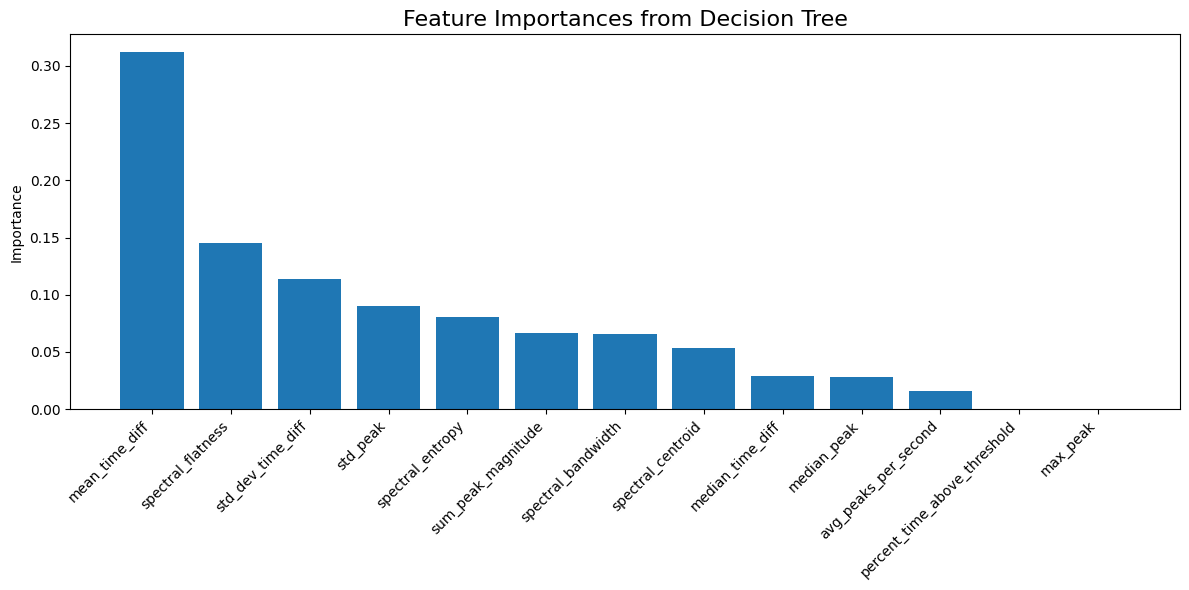

In [33]:
import numpy as np

# Get feature importances from the trained tree
importances = clf.feature_importances_
features = X_clean.columns

# Sort by importance
indices = np.argsort(importances)[::-1]
sorted_features = features[indices]
sorted_importances = importances[indices]

# Plot
plt.figure(figsize=(12, 6))
plt.title("Feature Importances from Decision Tree", fontsize=16)
plt.bar(range(len(sorted_features)), sorted_importances, align="center")
plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha='right')
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

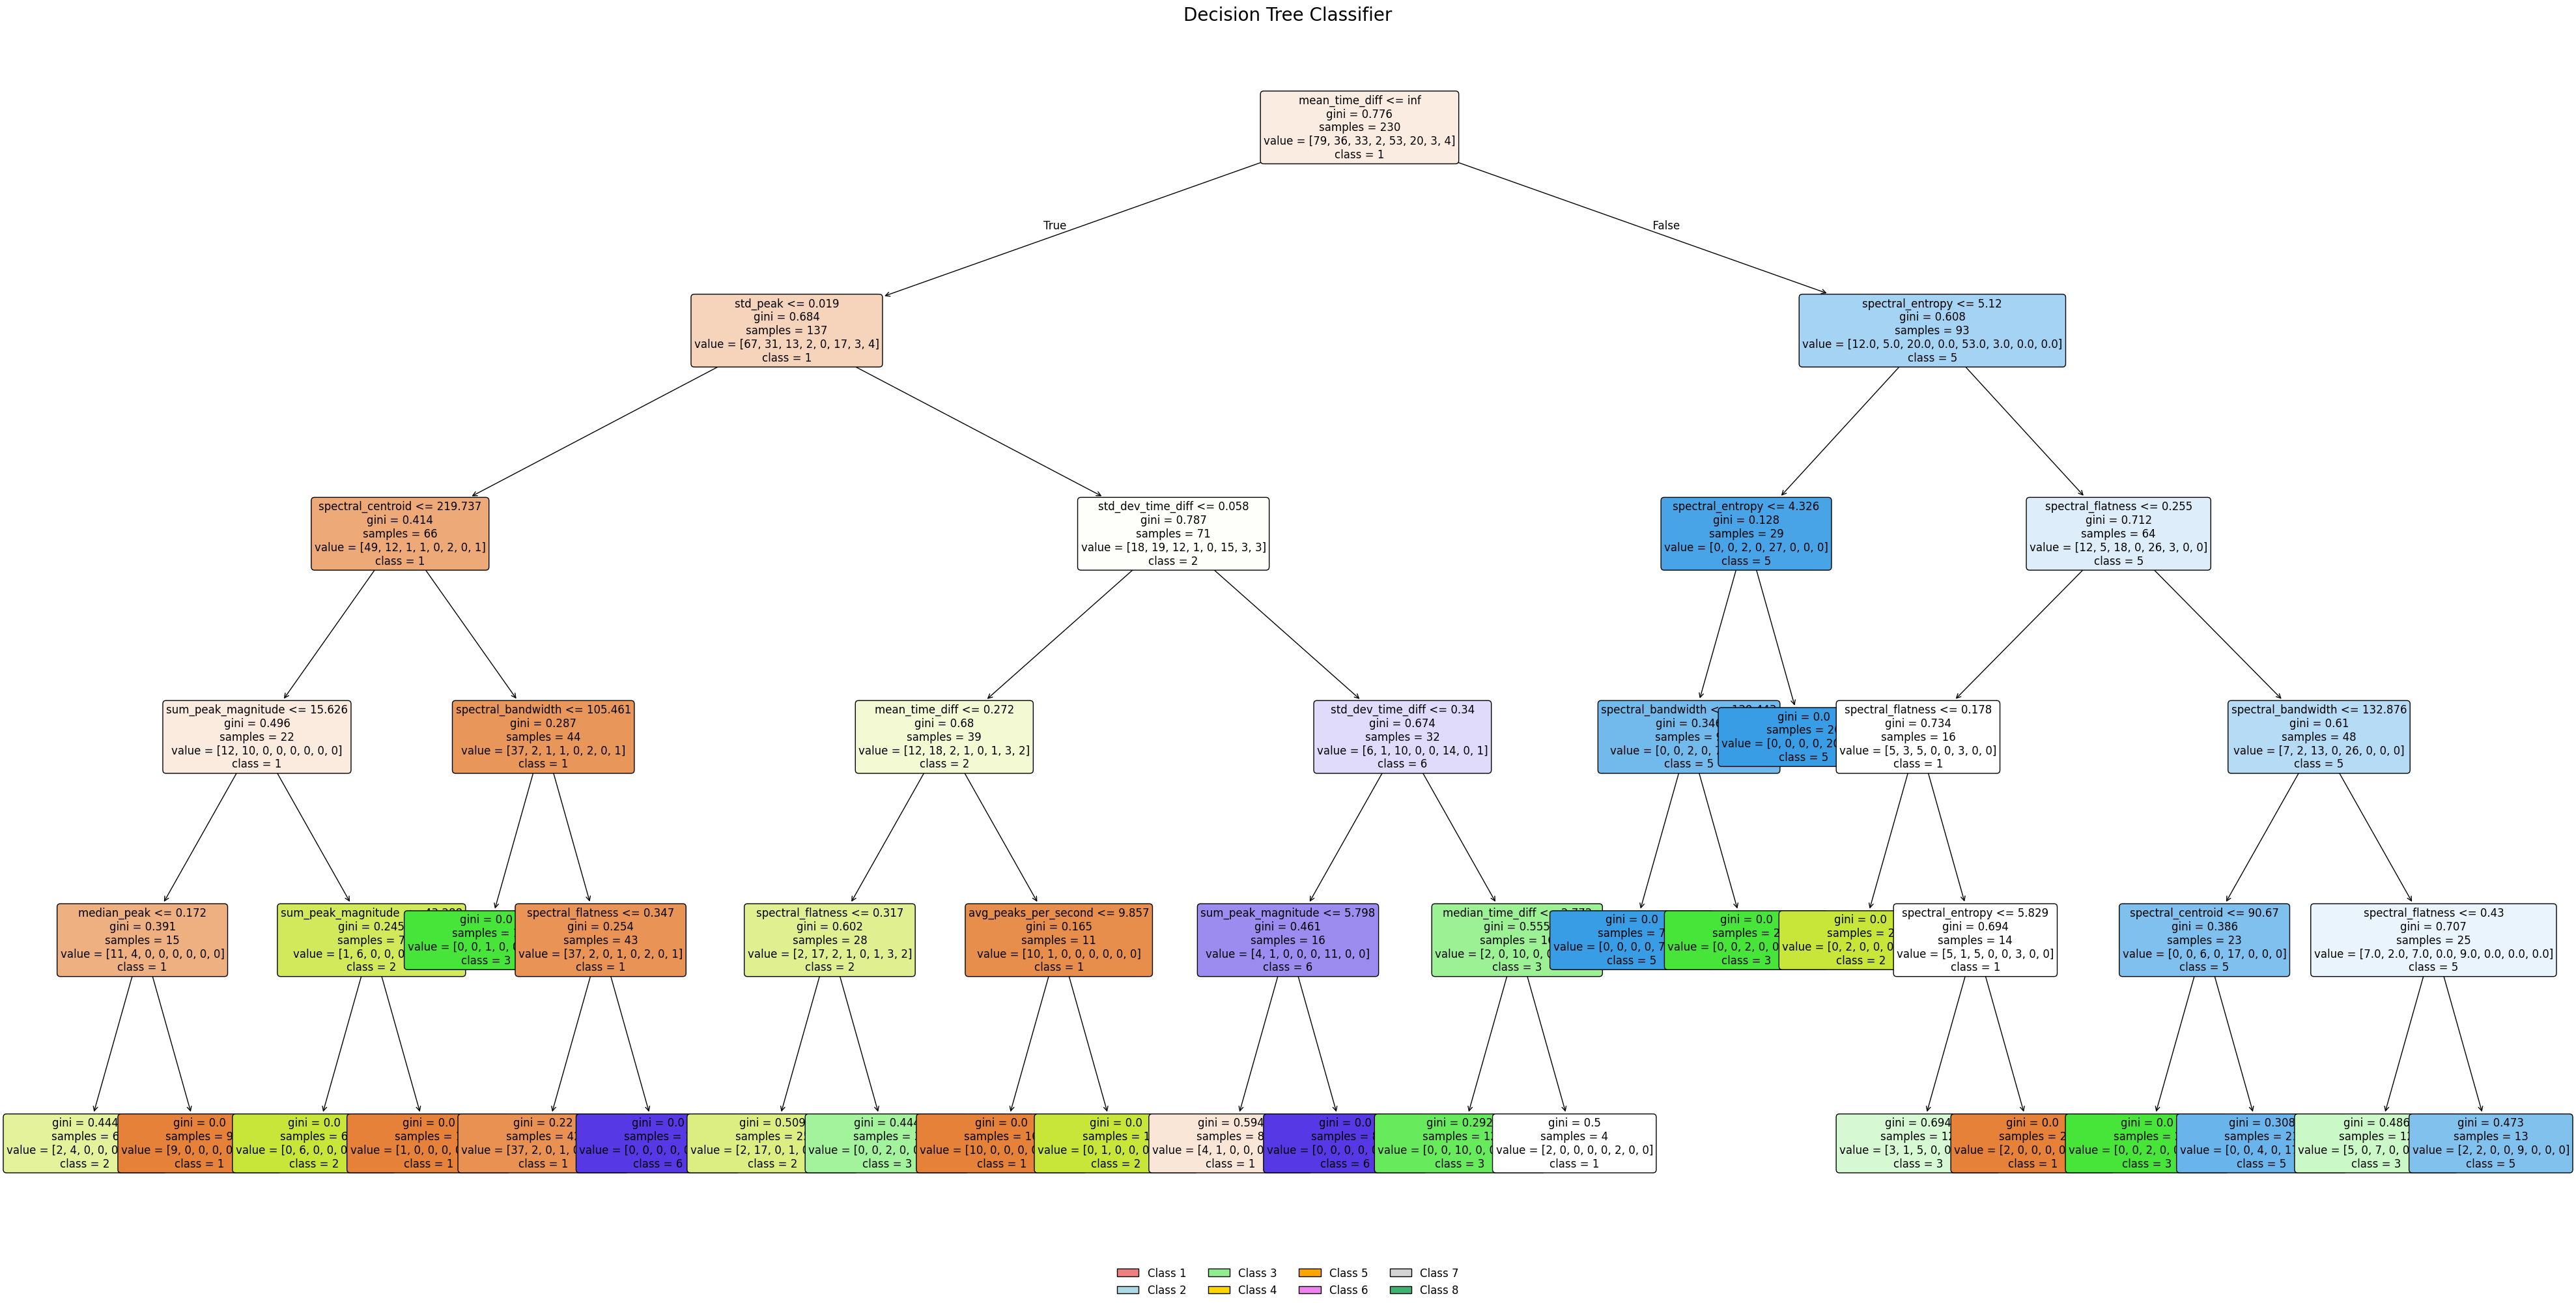

In [34]:
from matplotlib.patches import Patch

plt.figure(figsize=(40, 20))
plot_tree(
    clf,
    feature_names=X_clean.columns,
    class_names=[str(cls) for cls in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree Classifier", fontsize=20)

# Create legend for class colors (based on filled=True)
legend_elements = [
    Patch(facecolor='lightcoral', edgecolor='k', label='Class 1'),
    Patch(facecolor='lightblue', edgecolor='k', label='Class 2'),
    Patch(facecolor='lightgreen', edgecolor='k', label='Class 3'),
    Patch(facecolor='gold', edgecolor='k', label='Class 4'),
    Patch(facecolor='orange', edgecolor='k', label='Class 5'),
    Patch(facecolor='violet', edgecolor='k', label='Class 6'),
    Patch(facecolor='lightgray', edgecolor='k', label='Class 7'),
    Patch(facecolor='mediumseagreen', edgecolor='k', label='Class 8'),
]

plt.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.05),
           ncol=4, fontsize=12, frameon=False)
plt.tight_layout()
plt.show()

Merged rows: 288
Classification Report:
               precision    recall  f1-score   support

           1       0.77      0.85      0.81        20
           2       0.33      0.50      0.40         6
           3       0.78      0.70      0.74        10
           4       0.00      0.00      0.00         1
           5       0.90      0.90      0.90        10
           6       0.88      0.78      0.82         9
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1

    accuracy                           0.74        58
   macro avg       0.46      0.47      0.46        58
weighted avg       0.73      0.74      0.73        58

Confusion Matrix:
 [[17  2  1  0  0  0  0  0]
 [ 2  3  0  0  0  1  0  0]
 [ 1  1  7  0  1  0  0  0]
 [ 0  1  0  0  0  0  0  0]
 [ 0  1  0  0  9  0  0  0]
 [ 2  0  0  0  0  7  0  0]
 [ 0  0  1  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0]]


/Users/krishnanshugupta/Cal Poly/Acoustic-Space-Boiling/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/krishnanshugupta/Cal Poly/Acoustic-Space-Boiling/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/krishnanshugupta/Cal Poly/Acoustic-Space-Boiling/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` paramete

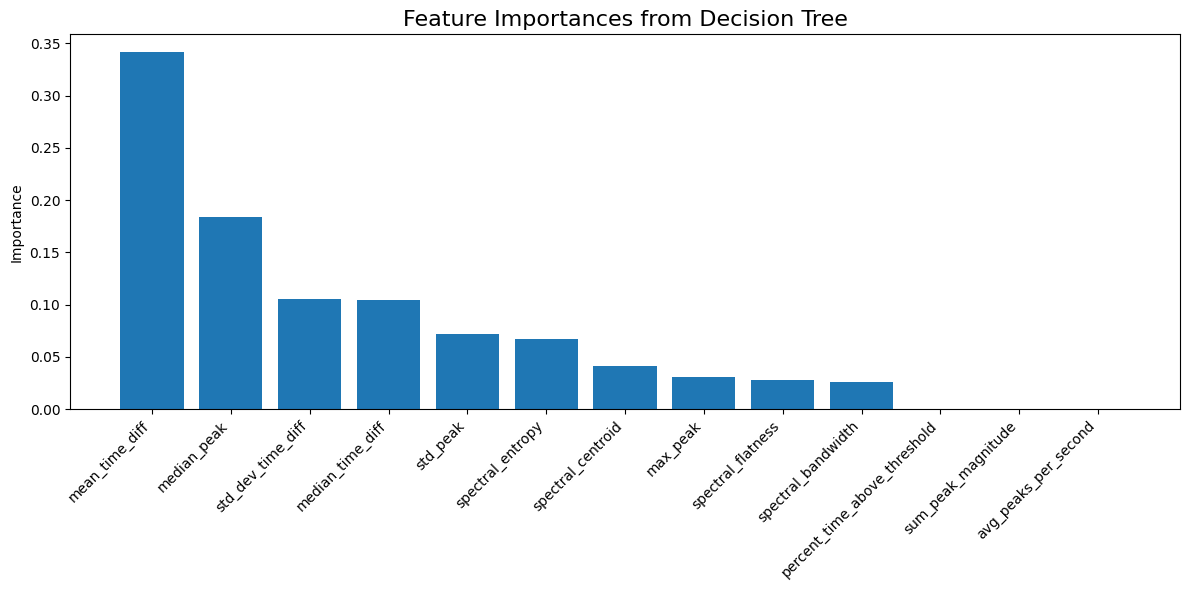

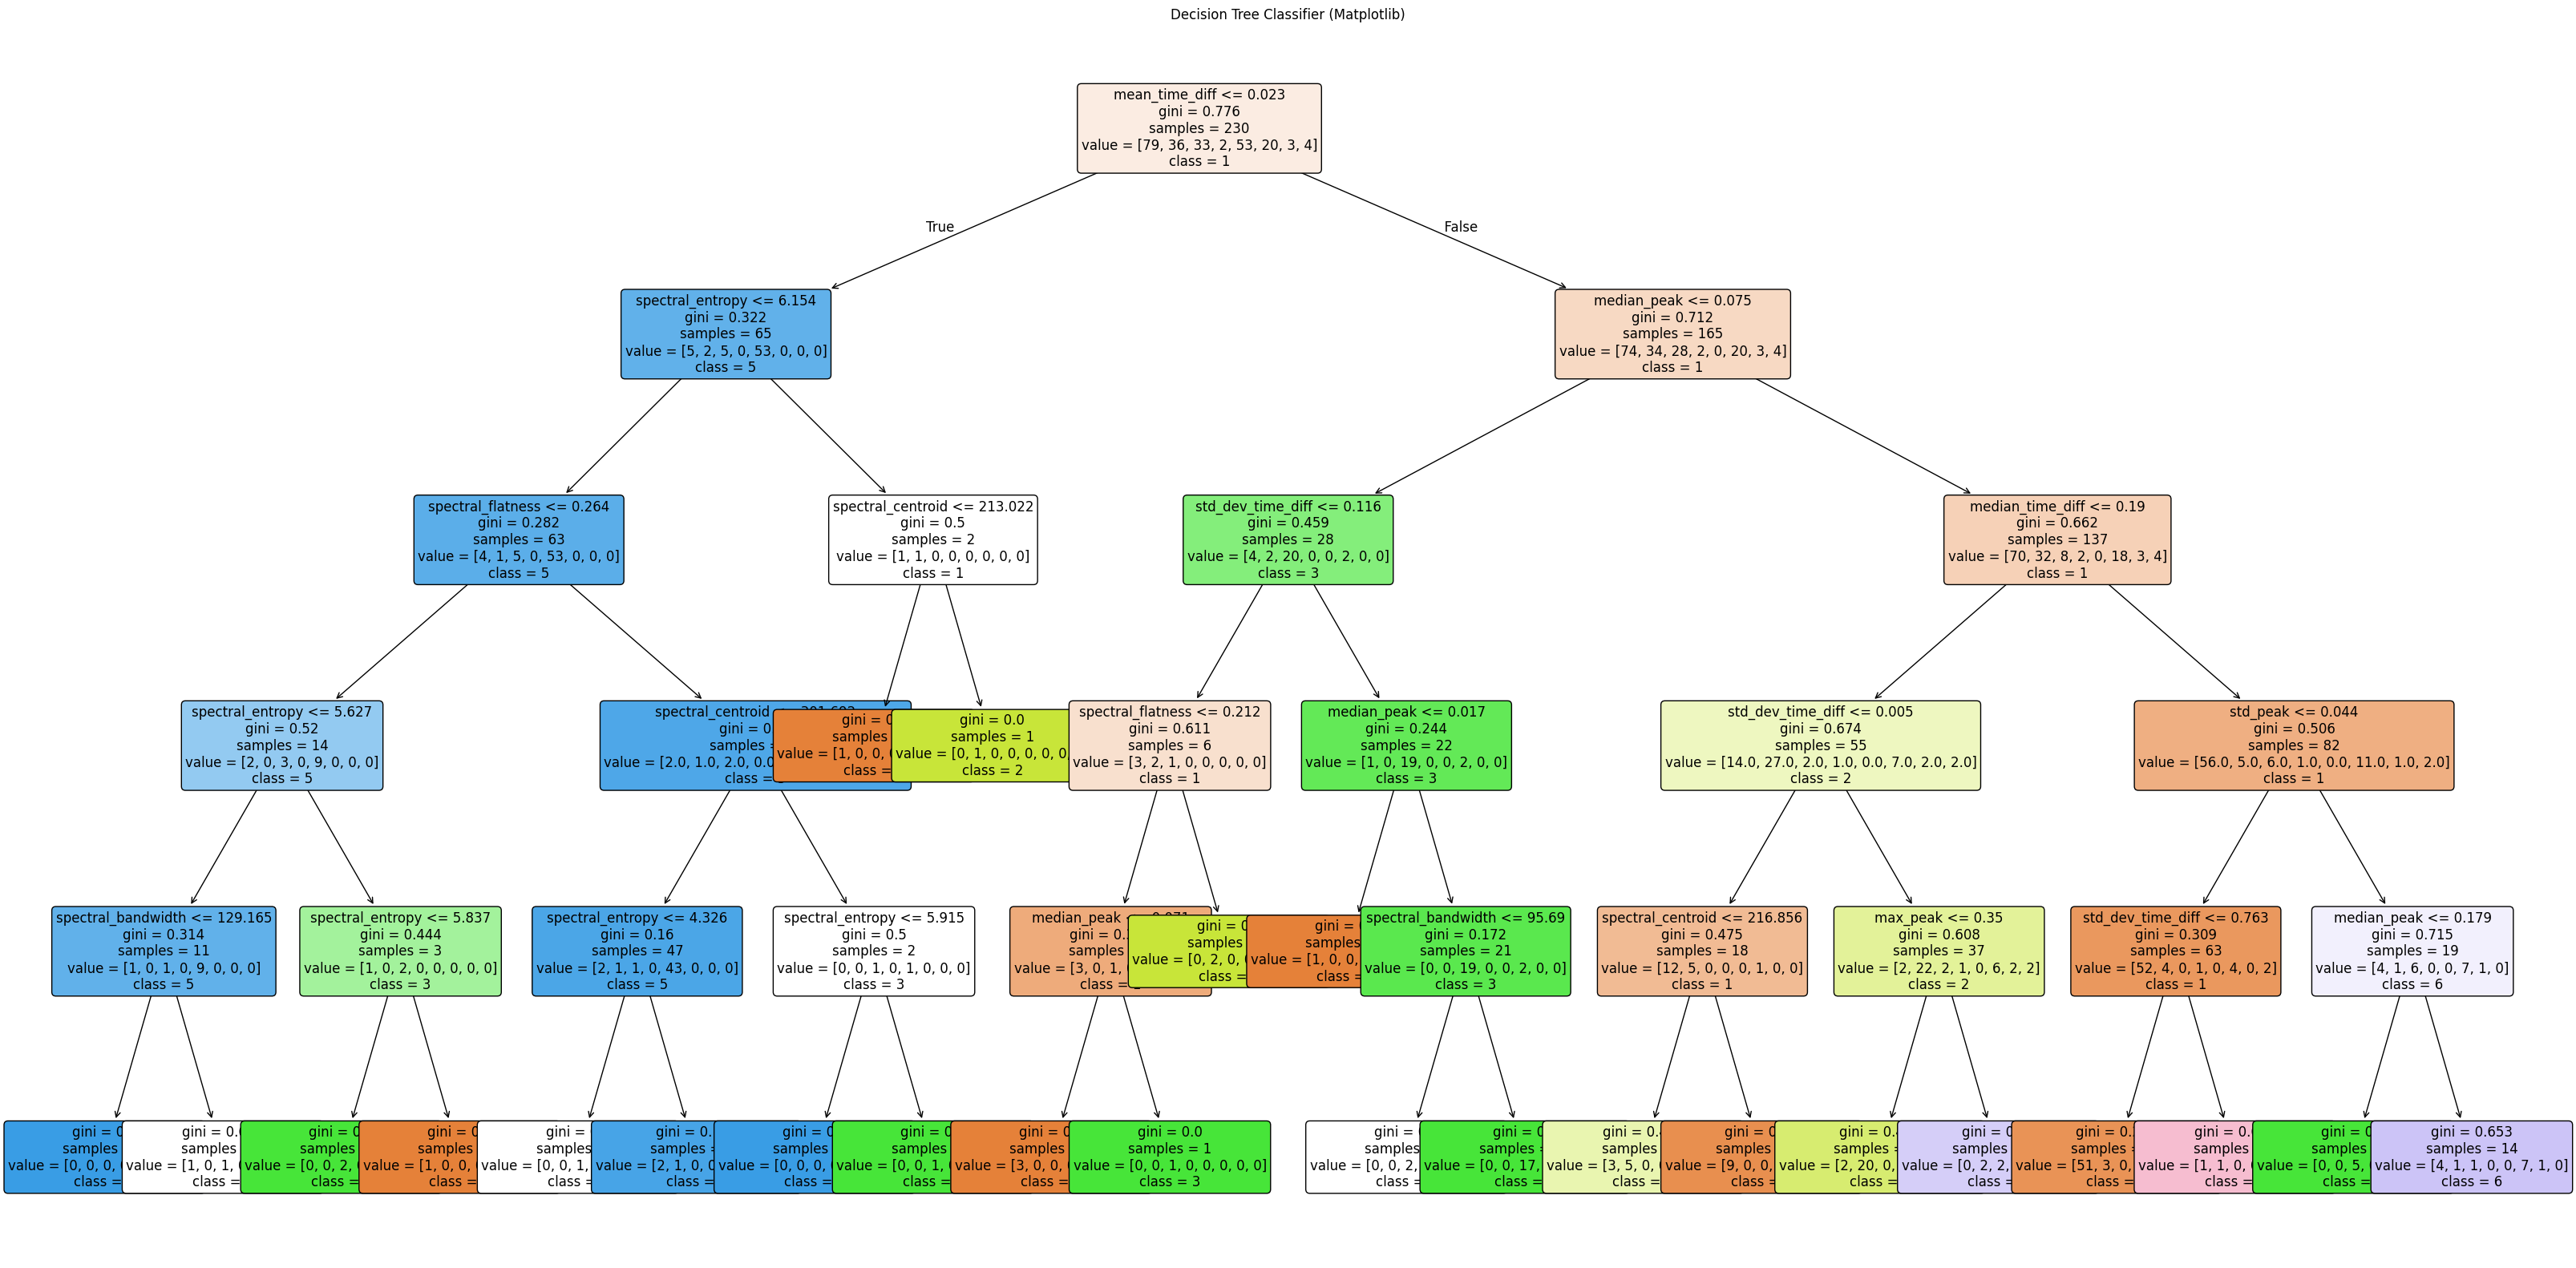

'tree_graphviz.pdf'

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import graphviz

# === 1. Load and clean data ===

# Load features
X = pd.read_csv("features.csv")

# Load labels (with header)
y_df = pd.read_csv("labels.csv")  # Assuming 'file_name' and 'label' columns exist

# Normalize 'file_name' in both DataFrames
X['file_name'] = X['file_name'].str.replace("Data/After_May/MATLAB ", "", regex=False).str.strip().str.lower()
y_df['file_name'] = y_df['file_name'].str.strip().str.lower()

# Merge on 'file_name'
df = pd.merge(X, y_df, on="file_name", how="inner")
print(f"Merged rows: {df.shape[0]}")

# Extract features and labels
y = df['label']
X_clean = df.drop(columns=['file_name', 'label'])

# === 2. Train/test split + train model ===
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# === 3. Evaluation ===
y_pred = clf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# === 4. Feature Importance Plot ===
importances = clf.feature_importances_
features = X_clean.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Feature Importances from Decision Tree", fontsize=16)
plt.bar(range(len(features)), importances[indices], align="center")
plt.xticks(range(len(features)), features[indices], rotation=45, ha='right')
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# === 5A. Plot Tree (Quick view, dynamic colors) ===
plt.figure(figsize=(40, 20))
plot_tree(
    clf,
    feature_names=X_clean.columns,
    class_names=[str(cls) for cls in sorted(y.unique())],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title("Decision Tree Classifier (Matplotlib)")
plt.show()

# === 5B. Graphviz Export (Consistent class colors, cleaner look) ===
dot_data = export_graphviz(
    clf,
    out_file=None,
    feature_names=X_clean.columns,
    class_names=[str(cls) for cls in sorted(y.unique())],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("tree_graphviz", format="png", cleanup=True)  # Saves as tree_graphviz.png
graph.view()  # Opens in system viewer
